In [1]:
import numpy as np
import tensorflow as tf 
import sys 
import pathlib
import json 
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
os.chdir('/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters/output/')
import version_Bin.model_pseudostate_original as model

In [2]:
###############################################################################
# 1. Define your export folder (trained model location) and parameters
###############################################################################
export_folder = "/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters/output/Novem_NewParaters_0.01_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_logxi_-3.0_logximax_5.0_num_iterations2000000"


batch_size                  =   128
num_iterations              = 2000000
logging_frequency           = 1000
learning_rates              = [10e-5, 10e-5, 10e-5, 10e-5]    # (10e-5 is 1e-4)
hidden_layer_activations    = ["swish","tanh","tanh","softplus"]
output_layer_activations    = ["softplus","custom","custom","softplus"]
num_hidden_layers           = 4
num_neurons                 = 32
learning_rate_schedule_type = "piecewiseconstant"
channel_type                = "full"
pretrained_path = None
tensorboard = True


## Take care of activation functions 
hidden_layer_activations   = [None if x == "None" else x for x in hidden_layer_activations]
output_layer_activations   = [None if x == "None" else x for x in output_layer_activations]


phi_g=16.7

v_nn_config   = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[0], "dim" : 1, "nn_name" : "v_nn"}
v_nn_config["final_activation"] = output_layer_activations[0]

i_g_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[1], "dim" : 1, "nn_name" : "i_g_nn"}
i_g_nn_config["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ phi_g) / (tf.exp(2 * x) + 1.0)

i_d_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[2], "dim" : 1, "nn_name" : "i_d_nn"}
i_d_nn_config["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ phi_g) / (tf.exp(2 * x) + 1.0)

i_I_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[3], "dim" : 1, "nn_name" : "i_I_nn"}
i_I_nn_config["final_activation"] = output_layer_activations[3]


## Create params struct 
params_post_tech_post_damage = {"batch_size" : batch_size, "learning_rates":learning_rates,\
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config,"i_I_nn_config":i_I_nn_config,\
"n_dims" : 3, "model_type" : "post_tech_post_damage" , \
"export_folder": export_folder +  "/post_tech_post_damage",
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, "load_parameters" : None,\
"pretrained_path" : pretrained_path, 'tensorboard' : tensorboard, "learning_rate_schedule_type" : learning_rate_schedule_type, "channel_type": channel_type }

 

params_post_tech_pre_damage = {"batch_size" : batch_size, "learning_rates":learning_rates,\
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config,"i_I_nn_config":i_I_nn_config,\
"n_dims" : 3, "model_type" : "post_tech_pre_damage",
"export_folder": export_folder +  "/post_tech_pre_damage",
"v_post_tech_post_damage_nn_path": export_folder + "/post_tech_post_damage",                               
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, "load_parameters" : None,\
"pretrained_path" : pretrained_path, 'tensorboard' : tensorboard, "learning_rate_schedule_type" : learning_rate_schedule_type, "channel_type": channel_type }


params_pre_tech_post_damage = {"batch_size" : batch_size, "learning_rates":learning_rates,\
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config,"i_I_nn_config":i_I_nn_config,\
"model_type":"pre_tech_post_damage",  "n_dims": 4,
"v_post_tech_post_damage_nn_path":  export_folder + "/post_tech_post_damage", "export_folder": export_folder +  "/pre_tech_post_damage",
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, "load_parameters" : None,\
"pretrained_path" : pretrained_path, 'tensorboard' : tensorboard, "learning_rate_schedule_type" : learning_rate_schedule_type, "channel_type": channel_type }


params_pre_tech_pre_damage = {"batch_size" : batch_size, "learning_rates":learning_rates,\
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config,"i_I_nn_config":i_I_nn_config,\
"n_dims" : 4, "model_type" : "pre_tech_pre_damage" , \
"v_pre_tech_post_damage_nn_path": export_folder + "/pre_tech_post_damage" , 
"v_post_tech_pre_damage_nn_path": export_folder + "/post_tech_pre_damage",
"export_folder": export_folder +  "/pre_tech_pre_damage",
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, "load_parameters" : None,\
"pretrained_path" : pretrained_path, 'tensorboard' : tensorboard, "learning_rate_schedule_type" : learning_rate_schedule_type, "channel_type": channel_type }

 
# params["v_pre_tech_post_damage_nn_path"]  = export_folder + "/pre_tech_post_damage"  
# params["v_post_tech_pre_damage_nn_path"]  = export_folder + "/post_tech_pre_damage"
# params["export_folder"]  = export_folder +  "/pre_tech_pre_damage"

  
## i_g and i_d activations come after params because we amy want to use phi_g and phi_d
# if output_layer_activations[1] == "custom" or output_layer_activations[2] == "custom":
#     params["i_g_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ params["phi_g"]) / (tf.exp(2 * x) + 1.0)
#     params["i_d_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ params["phi_d"]) / (tf.exp(2 * x) + 1.0)



In [3]:
# Define the paths: Load all for paths for simulation
export_folder = "/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters/output/Novem_NewParaters_0.01_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_logxi_-3.0_logximax_5.0_num_iterations2000000"

v_nn_checkpoint_post_tech_post_damage_path = export_folder+  "/post_tech_post_damage"+'/v_nn_checkpoint_post_tech_post_damage'
i_g_nn_checkpoint_post_tech_post_damage_path = export_folder+  "/post_tech_post_damage"+'/i_g_nn_checkpoint_post_tech_post_damage'
i_d_nn_checkpoint_post_tech_post_damage_path = export_folder+  "/post_tech_post_damage"+'/i_d_nn_checkpoint_post_tech_post_damage' 

v_nn_checkpoint_post_tech_pre_damage_path = export_folder+  "/post_tech_pre_damage"+'/v_nn_checkpoint_post_tech_pre_damage'
i_g_nn_checkpoint_post_tech_pre_damage_path = export_folder+  "/post_tech_pre_damage"+'/i_g_nn_checkpoint_post_tech_pre_damage'
i_d_nn_checkpoint_post_tech_pre_damage_path = export_folder+  "/post_tech_pre_damage"+'/i_d_nn_checkpoint_post_tech_pre_damage' 

v_nn_checkpoint_pre_tech_post_damage_path = export_folder+  "/pre_tech_post_damage"+'/v_nn_checkpoint_pre_tech_post_damage'
i_g_nn_checkpoint_pre_tech_post_damage_path = export_folder+  "/pre_tech_post_damage"+'/i_g_nn_checkpoint_pre_tech_post_damage'
i_d_nn_checkpoint_pre_tech_post_damage_path = export_folder+  "/pre_tech_post_damage"+'/i_d_nn_checkpoint_pre_tech_post_damage' 
i_I_nn_checkpoint_pre_tech_post_damage_path = export_folder+  "/pre_tech_post_damage"+'/i_I_nn_checkpoint_pre_tech_post_damage' 

v_nn_checkpoint_pre_tech_pre_damage_path = export_folder+  "/pre_tech_pre_damage"+'/v_nn_checkpoint_pre_tech_pre_damage'
i_g_nn_checkpoint_pre_tech_pre_damage_path = export_folder+  "/pre_tech_pre_damage"+'/i_g_nn_checkpoint_pre_tech_pre_damage'
i_d_nn_checkpoint_pre_tech_pre_damage_path = export_folder+  "/pre_tech_pre_damage"+'/i_d_nn_checkpoint_pre_tech_pre_damage' 
i_I_nn_checkpoint_pre_tech_pre_damage_path = export_folder+  "/pre_tech_pre_damage"+'/i_I_nn_checkpoint_pre_tech_pre_damage' 

In [4]:

def load_model(params, n_inputs, v_nn_checkpoint_path, i_g_nn_checkpoint_path, i_d_nn_checkpoint_path,i_I_nn_checkpoint_path=None):
    test_model = model.model(params)
    
    # n_inputs = 7 # if "post_tech_post_damage" in params["model_type"] else 8
    test_model.v_nn.build((params["batch_size"], n_inputs))
    test_model.i_g_nn.build((params["batch_size"], n_inputs))
    test_model.i_d_nn.build((params["batch_size"], n_inputs)) 
    
    test_model.v_nn.load_weights(v_nn_checkpoint_path)
    test_model.i_g_nn.load_weights(i_g_nn_checkpoint_path)
    test_model.i_d_nn.load_weights(i_d_nn_checkpoint_path) 
    
    if i_I_nn_checkpoint_path is not None:
        test_model.i_I_nn.build((params["batch_size"], n_inputs)) 
        test_model.i_I_nn.load_weights(i_I_nn_checkpoint_path) 
    return test_model

In [5]:
 
post_tech_post_damage_model = load_model(params_post_tech_post_damage,7, v_nn_checkpoint_post_tech_post_damage_path, i_g_nn_checkpoint_post_tech_post_damage_path, i_d_nn_checkpoint_post_tech_post_damage_path)
 
post_tech_pre_damage_model = load_model(params_post_tech_pre_damage,6, v_nn_checkpoint_post_tech_pre_damage_path, i_g_nn_checkpoint_post_tech_pre_damage_path, i_d_nn_checkpoint_post_tech_pre_damage_path)


pre_tech_post_damage_model = load_model(params_pre_tech_post_damage,8, v_nn_checkpoint_pre_tech_post_damage_path, i_g_nn_checkpoint_pre_tech_post_damage_path, i_d_nn_checkpoint_pre_tech_post_damage_path, i_I_nn_checkpoint_pre_tech_post_damage_path)

pre_tech_pre_damage_model = load_model(params_pre_tech_pre_damage,7, v_nn_checkpoint_pre_tech_pre_damage_path, i_g_nn_checkpoint_pre_tech_pre_damage_path, i_d_nn_checkpoint_pre_tech_pre_damage_path, i_I_nn_checkpoint_pre_tech_pre_damage_path)

Tensorboard boolean = True
Tensorboard boolean = True
Tensorboard boolean = True
Pre tech model detected. Building a neural network for i_I
Tensorboard boolean = True
Pre tech model detected. Building a neural network for i_I


In [6]:
post_tech_pre_damage_model.params["model_type"]

'post_tech_pre_damage'

Average PDE residual: 4.39e-03


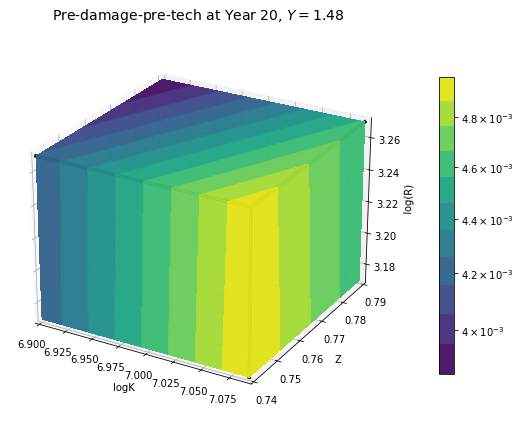

In [26]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def sample_pre_damage_pre_tech(Y=1.5 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_logIg  = 20

    logK_vals  = np.linspace(6.90, 7.09, N_logK)
    R_vals     = np.linspace(0.74, 0.79, N_R)
    logIg_vals = np.linspace(3.17, 3.27, N_logIg)
#     logIg_vals = np.linspace(0.0, 3.27, N_logIg)

    # Build a mesh
    LOGK, RRR, LOGIG = np.meshgrid(logK_vals, R_vals, logIg_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), LOGIG.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_logIg = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1]
    tf_Y           = tf.ones((num_points, 1), dtype=tf.float32) * Y  # Y=1.5
    tf_gamma_3     = tf.zeros((num_points, 1), dtype=tf.float32)       # gamma_3=0
    tf_A_g_prime   = tf.zeros((num_points, 1), dtype=tf.float32)       # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = pre_tech_pre_damage_model.params["batch_size"]
    pre_tech_pre_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = pre_tech_pre_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base,
    log_I_g          = tf_logIg, 
    training         = False
    )

    # Restore original batch size
    pre_tech_pre_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_logIg),LOGK , RRR,LOGIG

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
def plot3D_pre_damage_pre_tech(data_reshaped,X,Y,Z ):

 
    # Example shapes for your grid
    N_logK   = 20
    N_R      = 20
    N_logIg  = 20

    # Reshape PDE residual from (N_logK*N_R*N_logIg,) to (N_logK, N_R, N_logIg)
    # data_reshaped = pde_res_aggregated.reshape(N_logK, N_R, N_logIg)

    # For clarity, rename the coordinate grids (each shape is (N_logK, N_R, N_logIg)):
    # X = LOGK    # "logK" dimension
    # Y = RRR     # "R" dimension
    # Z = LOGIG   # "log_I_g" dimension

    # Coordinate minima and maxima
    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()   # This includes the "Rmin" face
    z_min, z_max = Z.min(), Z.max()

    # Contour levels spanning the data range
    vmin = data_reshaped.min()
    vmax = data_reshaped.max()
    levels = np.linspace(vmin, vmax, 12)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # Common settings for all surfaces
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.96)


    # 2) Z = z_max (back face)
    c2 = ax.contourf(
    X[:, :, -1],
    Y[:, :, -1],
    data_reshaped[:, :, -1],
    zdir='z', offset=z_max,
    **contour_kw
    )

    # 3) Y = y_min (left face: Rmin)
    c3 = ax.contourf(
    X[:, 0, :],               # shape (N_logK, N_logIg)
    data_reshaped[:, 0, :],   # shape (N_logK, N_logIg)
    Z[:, 0, :],               # shape (N_logK, N_logIg)
    zdir='y', offset=y_min,
    **contour_kw
    )



    # 6) X = x_max (far face)
    c6 = ax.contourf(
    data_reshaped[-1, :, :],
    Y[-1, :, :],
    Z[-1, :, :],
    zdir='x', offset=x_max,
    **contour_kw
    )

    # Set axis limits to form the rectangular "box"
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)

    # Axis labels
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("log(R)")


    edge_color, edge_lw = 'black', 3.5
#     ax.plot([x_min, x_max], [y_min, y_min], [z_min, z_min], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_max], [y_max, y_max], [z_min, z_min], color=edge_color, linewidth=edge_lw)
    ax.plot([x_min, x_max], [y_min, y_min], [z_max, z_max], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_max], [y_max, y_max], [z_max, z_max], color=edge_color, linewidth=edge_lw)

#     ax.plot([x_min, x_min], [y_min, y_max], [z_min, z_min], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_max, x_max], [y_min, y_max], [z_min, z_min], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_min], [y_min, y_max], [z_max, z_max], color=edge_color, linewidth=edge_lw)
    ax.plot([x_max, x_max], [y_min, y_max], [z_max, z_max], color=edge_color, linewidth=edge_lw)

#     ax.plot([x_min, x_min], [y_min, y_min], [z_min, z_max], color=edge_color, linewidth=edge_lw)
    ax.plot([x_max, x_max], [y_min, y_min], [z_min, z_max], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_min], [y_max, y_max], [z_min, z_max], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_max, x_max], [y_max, y_max], [z_min, z_max], color=edge_color, linewidth=edge_lw)


    # Adjust the viewing angle so you can see multiple faces
    ax.view_init(elev=25, azim=-60)
 
 

    # Attach a colorbar to the last contour set drawn
    cb = fig.colorbar(c6, ax=ax, fraction=0.03, pad=0.1 ) 
    
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()

    # cb.set_label('Mean PDE residual (log scale)', rotation=270, labelpad=15)

    
    
    ax.set_title(r'Pre-damage-pre-tech at Year 20, $Y=1.48$', fontsize=14, pad=15)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-4, -4))
    cb.ax.yaxis.set_major_formatter(formatter)
    cb.update_ticks()
    
    
    
    plt.tight_layout()
    plt.show() 
    
    
data_reshaped,X,Y,Z=sample_pre_damage_pre_tech(Y=1.48, log_xi=-1)

  

print("Average PDE residual: {:.2e}".format(np.mean(data_reshaped)))

plot3D_pre_damage_pre_tech(data_reshaped,X,Y,Z)

Average PDE residual over Y∈[1.30, 1.66]: 4.39e-03


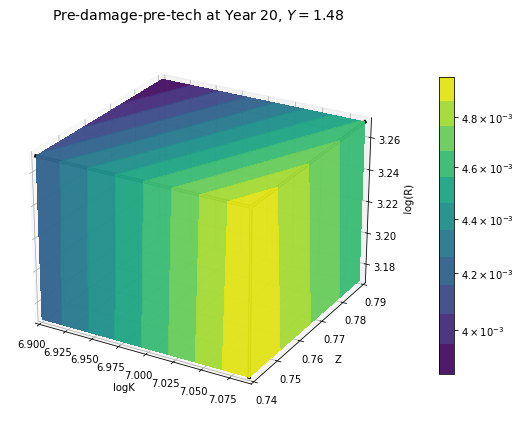

In [27]:
 
# 1) choose your grid in Y
N_Y   = 20
Y_vals = np.linspace(1.30, 1.66, N_Y)

# 2) collect residuals for each Y
residuals = []
for Y_val in Y_vals:
    data_i, X, Y_mesh, Z = sample_pre_damage_pre_tech(Y=Y_val, log_xi=-1)
    residuals.append(data_i)

# 3) stack into shape (N_Y, N_logK, N_R, N_logIg)
residuals = np.stack(residuals, axis=0)

# 4) average over Y
mean_residual = residuals.mean(axis=0)

# 5) report
print(f"Average PDE residual over Y∈[{Y_vals[0]:.2f}, {Y_vals[-1]:.2f}]: "
      f"{mean_residual.mean():.2e}")

# 6) re-use your existing mesh (X, Y_mesh, Z) from the last call
plot3D_pre_damage_pre_tech(mean_residual, X, Y_mesh, Z)


Average PDE residual: 5.03e-03


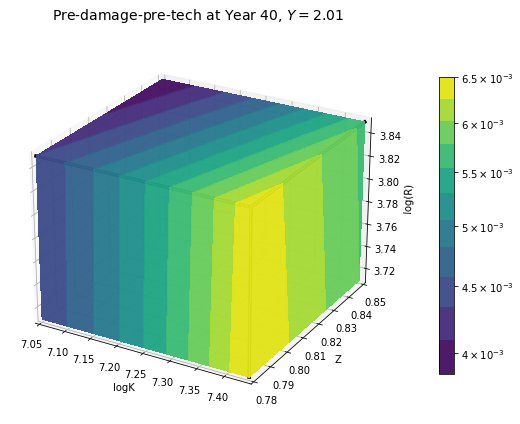

In [29]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def sample_pre_damage_pre_tech(Y=1.5 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_logIg  = 20

    logK_vals  = np.linspace(7.05, 7.44, N_logK)
    R_vals     = np.linspace(0.78, 0.85, N_R)
    logIg_vals = np.linspace(3.71, 3.85, N_logIg)
#     logIg_vals = np.linspace(0.0, 3.27, N_logIg)

    # Build a mesh
    LOGK, RRR, LOGIG = np.meshgrid(logK_vals, R_vals, logIg_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), LOGIG.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_logIg = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1]
    tf_Y           = tf.ones((num_points, 1), dtype=tf.float32) * Y  # Y=1.5
    tf_gamma_3     = tf.zeros((num_points, 1), dtype=tf.float32)       # gamma_3=0
    tf_A_g_prime   = tf.zeros((num_points, 1), dtype=tf.float32)       # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = pre_tech_pre_damage_model.params["batch_size"]
    pre_tech_pre_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = pre_tech_pre_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base,
    log_I_g          = tf_logIg, 
    training         = False
    )

    # Restore original batch size
    pre_tech_pre_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_logIg),LOGK , RRR,LOGIG

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
def plot3D_pre_damage_pre_tech(data_reshaped,X,Y,Z ):

 
    # Example shapes for your grid
    N_logK   = 20
    N_R      = 20
    N_logIg  = 20

    # Reshape PDE residual from (N_logK*N_R*N_logIg,) to (N_logK, N_R, N_logIg)
    # data_reshaped = pde_res_aggregated.reshape(N_logK, N_R, N_logIg)

    # For clarity, rename the coordinate grids (each shape is (N_logK, N_R, N_logIg)):
    # X = LOGK    # "logK" dimension
    # Y = RRR     # "R" dimension
    # Z = LOGIG   # "log_I_g" dimension

    # Coordinate minima and maxima
    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()   # This includes the "Rmin" face
    z_min, z_max = Z.min(), Z.max()

    # Contour levels spanning the data range
    vmin = data_reshaped.min()
    vmax = data_reshaped.max()
    levels = np.linspace(vmin, vmax, 12)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # Common settings for all surfaces
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.96)


    # 2) Z = z_max (back face)
    c2 = ax.contourf(
    X[:, :, -1],
    Y[:, :, -1],
    data_reshaped[:, :, -1],
    zdir='z', offset=z_max,
    **contour_kw
    )

    # 3) Y = y_min (left face: Rmin)
    c3 = ax.contourf(
    X[:, 0, :],               # shape (N_logK, N_logIg)
    data_reshaped[:, 0, :],   # shape (N_logK, N_logIg)
    Z[:, 0, :],               # shape (N_logK, N_logIg)
    zdir='y', offset=y_min,
    **contour_kw
    )



    # 6) X = x_max (far face)
    c6 = ax.contourf(
    data_reshaped[-1, :, :],
    Y[-1, :, :],
    Z[-1, :, :],
    zdir='x', offset=x_max,
    **contour_kw
    )

    # Set axis limits to form the rectangular "box"
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)

    # Axis labels
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("log(R)")


    edge_color, edge_lw = 'black', 3.5
#     ax.plot([x_min, x_max], [y_min, y_min], [z_min, z_min], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_max], [y_max, y_max], [z_min, z_min], color=edge_color, linewidth=edge_lw)
    ax.plot([x_min, x_max], [y_min, y_min], [z_max, z_max], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_max], [y_max, y_max], [z_max, z_max], color=edge_color, linewidth=edge_lw)

#     ax.plot([x_min, x_min], [y_min, y_max], [z_min, z_min], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_max, x_max], [y_min, y_max], [z_min, z_min], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_min], [y_min, y_max], [z_max, z_max], color=edge_color, linewidth=edge_lw)
    ax.plot([x_max, x_max], [y_min, y_max], [z_max, z_max], color=edge_color, linewidth=edge_lw)

#     ax.plot([x_min, x_min], [y_min, y_min], [z_min, z_max], color=edge_color, linewidth=edge_lw)
    ax.plot([x_max, x_max], [y_min, y_min], [z_min, z_max], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_min], [y_max, y_max], [z_min, z_max], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_max, x_max], [y_max, y_max], [z_min, z_max], color=edge_color, linewidth=edge_lw)


    # Adjust the viewing angle so you can see multiple faces
    ax.view_init(elev=25, azim=-60)
 
 

    # Attach a colorbar to the last contour set drawn
    cb = fig.colorbar(c6, ax=ax, fraction=0.03, pad=0.1 ) 
    
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()

    # cb.set_label('Mean PDE residual (log scale)', rotation=270, labelpad=15)

    
    
    ax.set_title(r'Pre-damage-pre-tech at Year 40, $Y=2.01$', fontsize=14, pad=15)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-4, -4))
    cb.ax.yaxis.set_major_formatter(formatter)
    cb.update_ticks()
    
    
    
    plt.tight_layout()
    plt.show() 
    
    
data_reshaped,X,Y,Z=sample_pre_damage_pre_tech(Y=2.01 , log_xi=-1)

print("Average PDE residual: {:.2e}".format(np.mean(data_reshaped)))

plot3D_pre_damage_pre_tech(data_reshaped,X,Y,Z)

Average PDE residual over Y∈[1.65, 2.36]: 5.12e-03


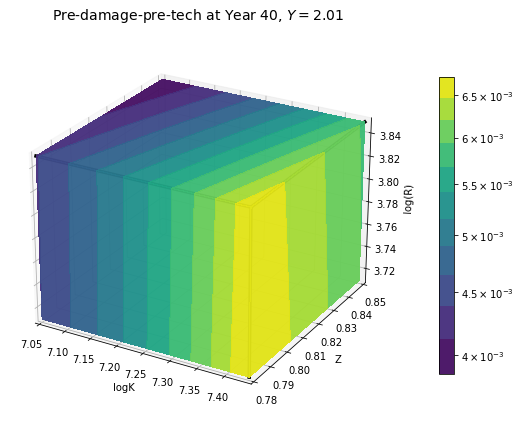

In [30]:
# 1) choose your grid in Y
N_Y   = 20
Y_vals = np.linspace(1.65, 2.36, N_Y)

# 2) collect residuals for each Y
residuals = []
for Y_val in Y_vals:
    data_i, X, Y_mesh, Z = sample_pre_damage_pre_tech(Y=Y_val, log_xi=-1)
    residuals.append(data_i)

# 3) stack into shape (N_Y, N_logK, N_R, N_logIg)
residuals = np.stack(residuals, axis=0)

# 4) average over Y
mean_residual = residuals.mean(axis=0)

# 5) report
print(f"Average PDE residual over Y∈[{Y_vals[0]:.2f}, {Y_vals[-1]:.2f}]: "
      f"{mean_residual.mean():.2e}")

# 6) re-use your existing mesh (X, Y_mesh, Z) from the last call
plot3D_pre_damage_pre_tech(mean_residual, X, Y_mesh, Z)


Average PDE residual: 1.10e-02


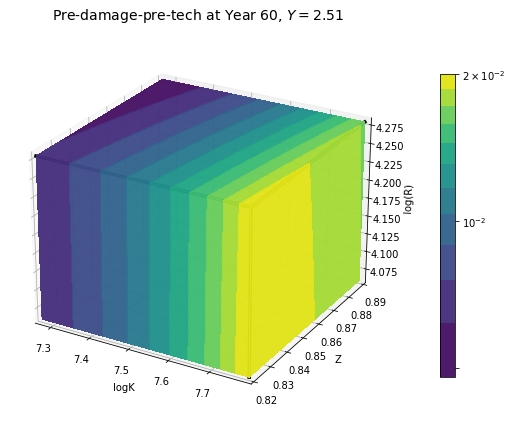

In [31]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def sample_pre_damage_pre_tech(Y=1.5 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_logIg  = 20
    
    logK_vals  = np.linspace(7.27, 7.79, N_logK)
    R_vals     = np.linspace(0.82, 0.89, N_R) 
     
    logIg_vals = np.linspace(4.06, 4.28, N_logIg)

    # Build a mesh
    LOGK, RRR, LOGIG = np.meshgrid(logK_vals, R_vals, logIg_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), LOGIG.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_logIg = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1]
    tf_Y           = tf.ones((num_points, 1), dtype=tf.float32) * Y  # Y=1.5
    tf_gamma_3     = tf.zeros((num_points, 1), dtype=tf.float32)       # gamma_3=0
    tf_A_g_prime   = tf.zeros((num_points, 1), dtype=tf.float32)       # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = pre_tech_pre_damage_model.params["batch_size"]
    pre_tech_pre_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = pre_tech_pre_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base,
    log_I_g          = tf_logIg, 
    training         = False
    )

    # Restore original batch size
    pre_tech_pre_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_logIg),LOGK , RRR,LOGIG

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
def plot3D_pre_damage_pre_tech(data_reshaped,X,Y,Z ):

 
    # Example shapes for your grid
    N_logK   = 20
    N_R      = 20
    N_logIg  = 20

    # Reshape PDE residual from (N_logK*N_R*N_logIg,) to (N_logK, N_R, N_logIg)
    # data_reshaped = pde_res_aggregated.reshape(N_logK, N_R, N_logIg)

    # For clarity, rename the coordinate grids (each shape is (N_logK, N_R, N_logIg)):
    # X = LOGK    # "logK" dimension
    # Y = RRR     # "R" dimension
    # Z = LOGIG   # "log_I_g" dimension

    # Coordinate minima and maxima
    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()   # This includes the "Rmin" face
    z_min, z_max = Z.min(), Z.max()

    # Contour levels spanning the data range
    vmin = data_reshaped.min()
    vmax = data_reshaped.max()
    levels = np.linspace(vmin, vmax, 12)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # Common settings for all surfaces
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.96)


    # 2) Z = z_max (back face)
    c2 = ax.contourf(
    X[:, :, -1],
    Y[:, :, -1],
    data_reshaped[:, :, -1],
    zdir='z', offset=z_max,
    **contour_kw
    )

    # 3) Y = y_min (left face: Rmin)
    c3 = ax.contourf(
    X[:, 0, :],               # shape (N_logK, N_logIg)
    data_reshaped[:, 0, :],   # shape (N_logK, N_logIg)
    Z[:, 0, :],               # shape (N_logK, N_logIg)
    zdir='y', offset=y_min,
    **contour_kw
    )



    # 6) X = x_max (far face)
    c6 = ax.contourf(
    data_reshaped[-1, :, :],
    Y[-1, :, :],
    Z[-1, :, :],
    zdir='x', offset=x_max,
    **contour_kw
    )

    # Set axis limits to form the rectangular "box"
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)

    # Axis labels
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("log(R)")


    edge_color, edge_lw = 'black', 3.5
#     ax.plot([x_min, x_max], [y_min, y_min], [z_min, z_min], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_max], [y_max, y_max], [z_min, z_min], color=edge_color, linewidth=edge_lw)
    ax.plot([x_min, x_max], [y_min, y_min], [z_max, z_max], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_max], [y_max, y_max], [z_max, z_max], color=edge_color, linewidth=edge_lw)

#     ax.plot([x_min, x_min], [y_min, y_max], [z_min, z_min], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_max, x_max], [y_min, y_max], [z_min, z_min], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_min], [y_min, y_max], [z_max, z_max], color=edge_color, linewidth=edge_lw)
    ax.plot([x_max, x_max], [y_min, y_max], [z_max, z_max], color=edge_color, linewidth=edge_lw)

#     ax.plot([x_min, x_min], [y_min, y_min], [z_min, z_max], color=edge_color, linewidth=edge_lw)
    ax.plot([x_max, x_max], [y_min, y_min], [z_min, z_max], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_min, x_min], [y_max, y_max], [z_min, z_max], color=edge_color, linewidth=edge_lw)
#     ax.plot([x_max, x_max], [y_max, y_max], [z_min, z_max], color=edge_color, linewidth=edge_lw)


    # Adjust the viewing angle so you can see multiple faces
    ax.view_init(elev=25, azim=-60)
 
 

    # Attach a colorbar to the last contour set drawn
    cb = fig.colorbar(c6, ax=ax, fraction=0.03, pad=0.1 ) 
    
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()

    # cb.set_label('Mean PDE residual (log scale)', rotation=270, labelpad=15)

    
    
    ax.set_title(r'Pre-damage-pre-tech at Year 60, $Y=2.51$', fontsize=14, pad=15)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-4, -4))
    cb.ax.yaxis.set_major_formatter(formatter)
    cb.update_ticks()
    
    
    
    plt.tight_layout()
    plt.show() 
    
    
data_reshaped,X,Y,Z=sample_pre_damage_pre_tech(Y=2.51 , log_xi=-1)
print("Average PDE residual: {:.2e}".format(np.mean(data_reshaped)))

plot3D_pre_damage_pre_tech(data_reshaped,X,Y,Z)

Average PDE residual over Y∈[2.14, 2.87]: 1.30e-02


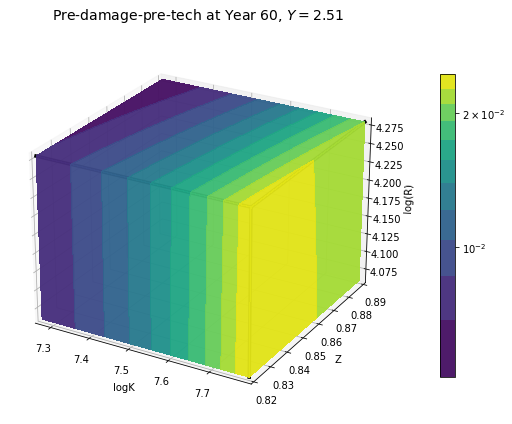

In [32]:
# 1) choose your grid in Y
N_Y   = 20
Y_vals = np.linspace(2.14, 2.87, N_Y)

# 2) collect residuals for each Y
residuals = []
for Y_val in Y_vals:
    data_i, X, Y_mesh, Z = sample_pre_damage_pre_tech(Y=Y_val, log_xi=-1)
    residuals.append(data_i)

# 3) stack into shape (N_Y, N_logK, N_R, N_logIg)
residuals = np.stack(residuals, axis=0)

# 4) average over Y
mean_residual = residuals.mean(axis=0)

# 5) report
print(f"Average PDE residual over Y∈[{Y_vals[0]:.2f}, {Y_vals[-1]:.2f}]: "
      f"{mean_residual.mean():.2e}")

# 6) re-use your existing mesh (X, Y_mesh, Z) from the last call
plot3D_pre_damage_pre_tech(mean_residual, X, Y_mesh, Z)


Average PDE residual: 4.39e-03


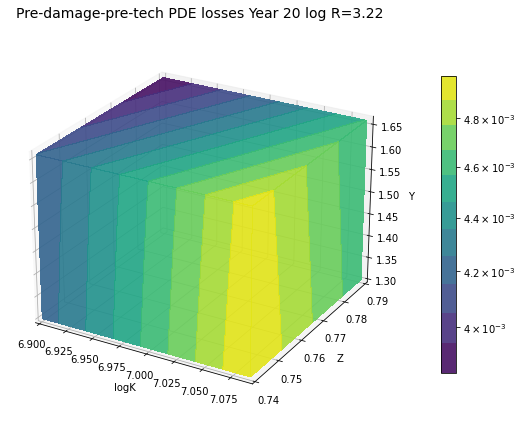

In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def sample_pre_damage_pre_tech_fixed_logIg(log_I_g=3.20, log_xi=-1.0):
    """
    Fix log_I_g at a constant, and build a 3‑D grid over (logK, R, Y).
    
    Returns:
      residual_grid: shape (N_logK, N_R, N_Y)
      LOGK, RRR, YYY : the 3D mesh arrays
    """
    # 1) grid resolution
    N_logK, N_R, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals = np.linspace(6.90, 7.09, N_logK)
    R_vals    = np.linspace(0.74, 0.79, N_R)
    Y_vals    = np.linspace(1.30, 1.66, N_Y)   # ← adjust min/max as needed

    # 3) make mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # 4) flatten for batch evaluation
    num_pts  = LOGK.size
    tf_logK    = tf.reshape(tf.constant(LOGK.ravel(),    dtype=tf.float32), [num_pts, 1])
    tf_R       = tf.reshape(tf.constant(RRR.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_Y       = tf.reshape(tf.constant(YYY.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_logIg   = tf.ones((num_pts,1), dtype=tf.float32) * log_I_g
    tf_gamma3  = tf.zeros((num_pts,1), dtype=tf.float32)
    tf_Agprime = tf.zeros((num_pts,1), dtype=tf.float32)
    tf_log_xi  = tf.ones((num_pts,1), dtype=tf.float32) * log_xi
    tf_log_xi_base = tf.zeros((num_pts,1), dtype=tf.float32)

    # 5) override batch size and evaluate
    old_bs = pre_tech_pre_damage_model.params["batch_size"]
    pre_tech_pre_damage_model.params["batch_size"] = num_pts

    outputs = pre_tech_pre_damage_model.pde_rhs(
        logK            = tf_logK,
        R               = tf_R,
        Y               = tf_Y,
        gamma_3         = tf_gamma3,
        A_g_prime       = tf_Agprime,
        log_xi          = tf_log_xi,
        log_xi_baseline = tf_log_xi_base,
        log_I_g         = tf_logIg,
        training        = False
    )

    pre_tech_pre_damage_model.params["batch_size"] = old_bs

    # 6) compute aggregated residual and reshape
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    residual_grid = resid.reshape(N_logK, N_R, N_Y)

    return residual_grid, LOGK, RRR, YYY


def plot3D_pre_damage_pre_tech_fixed_logIg(residual, LOGK, RRR, YYY, log_I_g):
    """
    Plot the 3‑D box contours of PDE residual over (logK, R, Y)
    at the fixed log_I_g level.
    """
    # axis limits
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    # contour levels
    vmin, vmax = residual.min(), residual.max()
    levels = np.linspace(vmin, vmax, 12)
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # -- face at Y = Y_max (top face) --
    c1 = ax.contourf(
        LOGK[:, :, -1],
        RRR[:, :, -1],
        residual[:, :, -1],
        zdir='z', offset=z_max,
        **contour_kw
    )

    # -- face at R = R_min (front face) --
    c2 = ax.contourf(
        LOGK[:, 0, :],
        residual[:, 0, :],
        YYY[:, 0, :],
        zdir='y', offset=y_min,
        **contour_kw
    )

    # -- face at logK = logK_max (side face) --
    c3 = ax.contourf(
        residual[-1, :, :],
        RRR[-1, :, :],
        YYY[-1, :, :],
        zdir='x', offset=x_max,
        **contour_kw
    )

    # set limits & labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    # colorbar & title
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    
    ax.set_title(f'Pre‑damage‑pre‑tech PDE losses Year 20 log R={log_I_g:.2f}',fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)

    plt.tight_layout()
    plt.show()


# --- usage example ---
res_grid, LOGK, RRR, YYY = sample_pre_damage_pre_tech_fixed_logIg(log_I_g=3.22, log_xi=-1.0)
print("Average PDE residual: {:.2e}".format(np.mean(res_grid)))

plot3D_pre_damage_pre_tech_fixed_logIg(res_grid, LOGK, RRR, YYY, log_I_g=3.22)


Average PDE residual: 5.12e-03


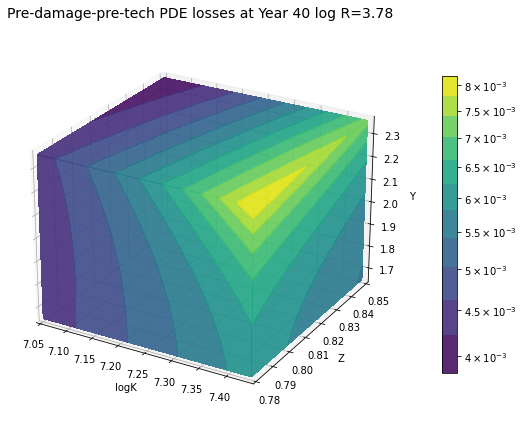

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def sample_pre_damage_pre_tech_fixed_logIg(log_I_g=3.20, log_xi=-1.0):
    """
    Fix log_I_g at a constant, and build a 3‑D grid over (logK, R, Y).
    
    Returns:
      residual_grid: shape (N_logK, N_R, N_Y)
      LOGK, RRR, YYY : the 3D mesh arrays
    """
    # 1) grid resolution
    N_logK, N_R, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(7.05, 7.44, N_logK)
    R_vals     = np.linspace(0.78, 0.85, N_R)
    Y_vals    = np.linspace(1.65, 2.36, N_Y)   # ← adjust min/max as needed

    # 3) make mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # 4) flatten for batch evaluation
    num_pts  = LOGK.size
    tf_logK    = tf.reshape(tf.constant(LOGK.ravel(),    dtype=tf.float32), [num_pts, 1])
    tf_R       = tf.reshape(tf.constant(RRR.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_Y       = tf.reshape(tf.constant(YYY.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_logIg   = tf.ones((num_pts,1), dtype=tf.float32) * log_I_g
    tf_gamma3  = tf.zeros((num_pts,1), dtype=tf.float32)
    tf_Agprime = tf.zeros((num_pts,1), dtype=tf.float32)
    tf_log_xi  = tf.ones((num_pts,1), dtype=tf.float32) * log_xi
    tf_log_xi_base = tf.zeros((num_pts,1), dtype=tf.float32)

    # 5) override batch size and evaluate
    old_bs = pre_tech_pre_damage_model.params["batch_size"]
    pre_tech_pre_damage_model.params["batch_size"] = num_pts

    outputs = pre_tech_pre_damage_model.pde_rhs(
        logK            = tf_logK,
        R               = tf_R,
        Y               = tf_Y,
        gamma_3         = tf_gamma3,
        A_g_prime       = tf_Agprime,
        log_xi          = tf_log_xi,
        log_xi_baseline = tf_log_xi_base,
        log_I_g         = tf_logIg,
        training        = False
    )

    pre_tech_pre_damage_model.params["batch_size"] = old_bs

    # 6) compute aggregated residual and reshape
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    residual_grid = resid.reshape(N_logK, N_R, N_Y)

    return residual_grid, LOGK, RRR, YYY


def plot3D_pre_damage_pre_tech_fixed_logIg(residual, LOGK, RRR, YYY, log_I_g):
    """
    Plot the 3‑D box contours of PDE residual over (logK, R, Y)
    at the fixed log_I_g level.
    """
    # axis limits
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    # contour levels
    vmin, vmax = residual.min(), residual.max()
    levels = np.linspace(vmin, vmax, 12)
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # -- face at Y = Y_max (top face) --
    c1 = ax.contourf(
        LOGK[:, :, -1],
        RRR[:, :, -1],
        residual[:, :, -1],
        zdir='z', offset=z_max,
        **contour_kw
    )

    # -- face at R = R_min (front face) --
    c2 = ax.contourf(
        LOGK[:, 0, :],
        residual[:, 0, :],
        YYY[:, 0, :],
        zdir='y', offset=y_min,
        **contour_kw
    )

    # -- face at logK = logK_max (side face) --
    c3 = ax.contourf(
        residual[-1, :, :],
        RRR[-1, :, :],
        YYY[-1, :, :],
        zdir='x', offset=x_max,
        **contour_kw
    )

    # set limits & labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    # colorbar & title
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    
    ax.set_title(f'Pre‑damage‑pre‑tech PDE losses at Year 40 log R={log_I_g:.2f}',fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)

    plt.tight_layout()
    plt.show()


# --- usage example ---
res_grid, LOGK, RRR, YYY = sample_pre_damage_pre_tech_fixed_logIg(log_I_g=3.78, log_xi=-1.0)
print("Average PDE residual: {:.2e}".format(np.mean(res_grid)))

plot3D_pre_damage_pre_tech_fixed_logIg(res_grid, LOGK, RRR, YYY, log_I_g=3.78)

Average PDE residual: 1.30e-02


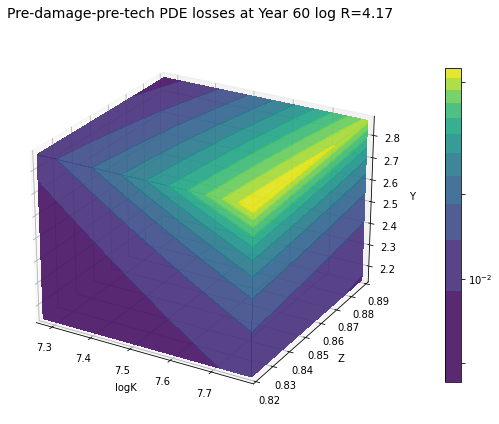

In [15]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def sample_pre_damage_pre_tech_fixed_logIg(log_I_g=3.20, log_xi=-1.0):
    """
    Fix log_I_g at a constant, and build a 3‑D grid over (logK, R, Y).
    
    Returns:
      residual_grid: shape (N_logK, N_R, N_Y)
      LOGK, RRR, YYY : the 3D mesh arrays
    """
    # 1) grid resolution
    N_logK, N_R, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(7.27, 7.79, N_logK)
    R_vals     = np.linspace(0.82, 0.89, N_R)
    Y_vals    = np.linspace(2.14, 2.87, N_Y)   # ← adjust min/max as needed

    # 3) make mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # 4) flatten for batch evaluation
    num_pts  = LOGK.size
    tf_logK    = tf.reshape(tf.constant(LOGK.ravel(),    dtype=tf.float32), [num_pts, 1])
    tf_R       = tf.reshape(tf.constant(RRR.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_Y       = tf.reshape(tf.constant(YYY.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_logIg   = tf.ones((num_pts,1), dtype=tf.float32) * log_I_g
    tf_gamma3  = tf.zeros((num_pts,1), dtype=tf.float32)
    tf_Agprime = tf.zeros((num_pts,1), dtype=tf.float32)
    tf_log_xi  = tf.ones((num_pts,1), dtype=tf.float32) * log_xi
    tf_log_xi_base = tf.zeros((num_pts,1), dtype=tf.float32)

    # 5) override batch size and evaluate
    old_bs = pre_tech_pre_damage_model.params["batch_size"]
    pre_tech_pre_damage_model.params["batch_size"] = num_pts

    outputs = pre_tech_pre_damage_model.pde_rhs(
        logK            = tf_logK,
        R               = tf_R,
        Y               = tf_Y,
        gamma_3         = tf_gamma3,
        A_g_prime       = tf_Agprime,
        log_xi          = tf_log_xi,
        log_xi_baseline = tf_log_xi_base,
        log_I_g         = tf_logIg,
        training        = False
    )

    pre_tech_pre_damage_model.params["batch_size"] = old_bs

    # 6) compute aggregated residual and reshape
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    residual_grid = resid.reshape(N_logK, N_R, N_Y)

    return residual_grid, LOGK, RRR, YYY


def plot3D_pre_damage_pre_tech_fixed_logIg(residual, LOGK, RRR, YYY, log_I_g):
    """
    Plot the 3‑D box contours of PDE residual over (logK, R, Y)
    at the fixed log_I_g level.
    """
    # axis limits
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    # contour levels
    vmin, vmax = residual.min(), residual.max()
    levels = np.linspace(vmin, vmax, 12)
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # -- face at Y = Y_max (top face) --
    c1 = ax.contourf(
        LOGK[:, :, -1],
        RRR[:, :, -1],
        residual[:, :, -1],
        zdir='z', offset=z_max,
        **contour_kw
    )

    # -- face at R = R_min (front face) --
    c2 = ax.contourf(
        LOGK[:, 0, :],
        residual[:, 0, :],
        YYY[:, 0, :],
        zdir='y', offset=y_min,
        **contour_kw
    )

    # -- face at logK = logK_max (side face) --
    c3 = ax.contourf(
        residual[-1, :, :],
        RRR[-1, :, :],
        YYY[-1, :, :],
        zdir='x', offset=x_max,
        **contour_kw
    )

    # set limits & labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    # colorbar & title
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    
    ax.set_title(f'Pre‑damage‑pre‑tech PDE losses at Year 60 log R={log_I_g:.2f}', fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)

    plt.tight_layout()
    plt.show()


# --- usage example ---
res_grid, LOGK, RRR, YYY = sample_pre_damage_pre_tech_fixed_logIg(log_I_g=4.17, log_xi=-1.0)
print("Average PDE residual: {:.2e}".format(np.mean(res_grid)))

plot3D_pre_damage_pre_tech_fixed_logIg(res_grid, LOGK, RRR, YYY, log_I_g=4.17)

Average PDE residual: 3.41e-03


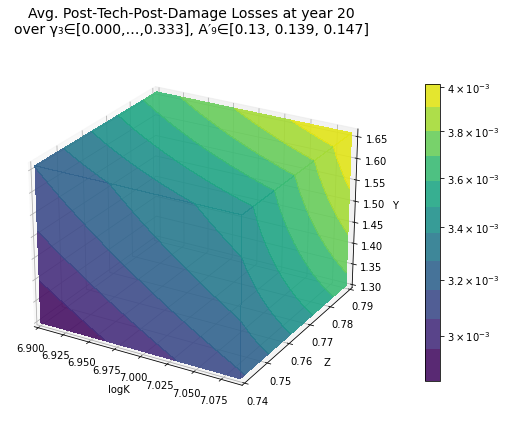

In [16]:
def sample_post_damage_post_tech(gamma_3=0.17,A_g_prime = 0.139 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_Y      = 20

    logK_vals  = np.linspace(6.9, 7.09, N_logK)
    R_vals     = np.linspace(0.74, 0.79, N_R)
    Y_vals = np.linspace(1.3, 1.66, N_Y)

    # Build a mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_gamma_3     = tf.ones((num_points, 1), dtype=tf.float32) * gamma_3       # gamma_3=0
    tf_A_g_prime   = tf.ones((num_points, 1), dtype=tf.float32) * A_g_prime      # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = post_tech_post_damage_model.params["batch_size"]
    post_tech_post_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = post_tech_post_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base, 
    training         = False
    )

    # Restore original batch size
    post_tech_post_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_Y),LOGK , RRR,YYY
# 1) Build the two parameter lists from your model.params
gamma_3_list   = np.linspace(
    post_tech_post_damage_model.params["gamma_3_min"],
    post_tech_post_damage_model.params["gamma_3_max"],
    post_tech_post_damage_model.params["gamma_3_length"]
)
A_g_prime_list = post_tech_post_damage_model.params["A_g_prime_list"]

# 2) Pre-allocate storage for all the loss grids
#    We’ll grab one sample to get N_logK, N_R, N_Y & the coordinate meshes
_example_res, LOGK, RRR, YYY = sample_post_damage_post_tech(
    gamma_3=gamma_3_list[0],
    A_g_prime=A_g_prime_list[0],
    log_xi=-1
)
N_logK, N_R, N_Y = _example_res.shape

all_res = np.zeros((len(gamma_3_list), len(A_g_prime_list),
                    N_logK, N_R, N_Y),
                   dtype=np.float32)

# 3) Loop and fill
for i, gamma_3 in enumerate(gamma_3_list):
    for j, A_g_prime in enumerate(A_g_prime_list):
        res_grid, _, _, _ = sample_post_damage_post_tech(
            gamma_3   = gamma_3,
            A_g_prime = A_g_prime,
            log_xi    = -1
        )
        all_res[i, j] = res_grid

# 4) Average over the first two axes (gamma_3 & A_g_prime)
mean_residual = all_res.mean(axis=(0,1))

print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 5) Plotting function for the averaged post‑post surface
def plot3D_post_damage_post_tech(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()
    
    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)
    
    fig = plt.figure(figsize=(8,6))
    ax  = fig.add_subplot(111, projection='3d')
    
    # face at Y = Y_max
    c1 = ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    c2 = ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")
    
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()    
    ax.set_title("Avg. Post‑Tech‑Post‑Damage Losses at year 20\n" +
                 f"over γ₃∈[{gamma_3_list[0]:.3f},…,{gamma_3_list[-1]:.3f}], " +
                 f"A′₉∈{A_g_prime_list}",
                 fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 6) Finally call it:
plot3D_post_damage_post_tech(mean_residual, LOGK, RRR, YYY)


Average PDE residual: 4.34e-03


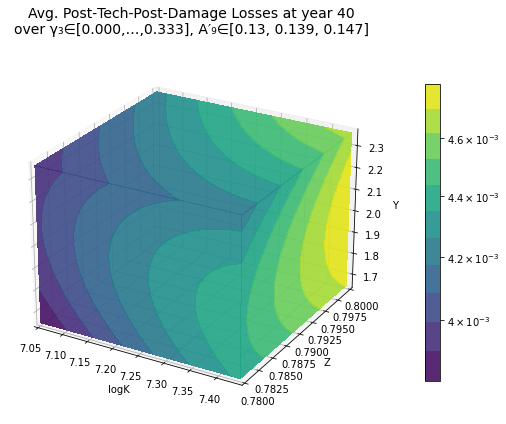

In [17]:
def sample_post_damage_post_tech(gamma_3=0.17,A_g_prime = 0.139 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_Y      = 20

    logK_vals  = np.linspace(7.05, 7.44, N_logK)
    R_vals     = np.linspace(0.78, 0.8, N_R)
    Y_vals = np.linspace(1.65, 2.36, N_Y)

    # Build a mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_gamma_3     = tf.ones((num_points, 1), dtype=tf.float32) * gamma_3       # gamma_3=0
    tf_A_g_prime   = tf.ones((num_points, 1), dtype=tf.float32) * A_g_prime      # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = post_tech_post_damage_model.params["batch_size"]
    post_tech_post_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = post_tech_post_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base, 
    training         = False
    )

    # Restore original batch size
    post_tech_post_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_Y),LOGK , RRR,YYY
# 1) Build the two parameter lists from your model.params
gamma_3_list   = np.linspace(
    post_tech_post_damage_model.params["gamma_3_min"],
    post_tech_post_damage_model.params["gamma_3_max"],
    post_tech_post_damage_model.params["gamma_3_length"]
)
A_g_prime_list = post_tech_post_damage_model.params["A_g_prime_list"]

# 2) Pre-allocate storage for all the loss grids
#    We’ll grab one sample to get N_logK, N_R, N_Y & the coordinate meshes
_example_res, LOGK, RRR, YYY = sample_post_damage_post_tech(
    gamma_3=gamma_3_list[0],
    A_g_prime=A_g_prime_list[0],
    log_xi=-1
)
N_logK, N_R, N_Y = _example_res.shape

all_res = np.zeros((len(gamma_3_list), len(A_g_prime_list),
                    N_logK, N_R, N_Y),
                   dtype=np.float32)

# 3) Loop and fill
for i, gamma_3 in enumerate(gamma_3_list):
    for j, A_g_prime in enumerate(A_g_prime_list):
        res_grid, _, _, _ = sample_post_damage_post_tech(
            gamma_3   = gamma_3,
            A_g_prime = A_g_prime,
            log_xi    = -1
        )
        all_res[i, j] = res_grid

# 4) Average over the first two axes (gamma_3 & A_g_prime)
mean_residual = all_res.mean(axis=(0,1))
print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 5) Plotting function for the averaged post‑post surface
def plot3D_post_damage_post_tech(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()
    
    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)
    
    fig = plt.figure(figsize=(8,6))
    ax  = fig.add_subplot(111, projection='3d')
    
    # face at Y = Y_max
    c1 = ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    c2 = ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")
    
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()    
    ax.set_title("Avg. Post‑Tech‑Post‑Damage Losses at year 40\n" +
                 f"over γ₃∈[{gamma_3_list[0]:.3f},…,{gamma_3_list[-1]:.3f}], " +
                 f"A′₉∈{A_g_prime_list}",
                fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 6) Finally call it:
plot3D_post_damage_post_tech(mean_residual, LOGK, RRR, YYY)


Average PDE residual: 5.88e-03


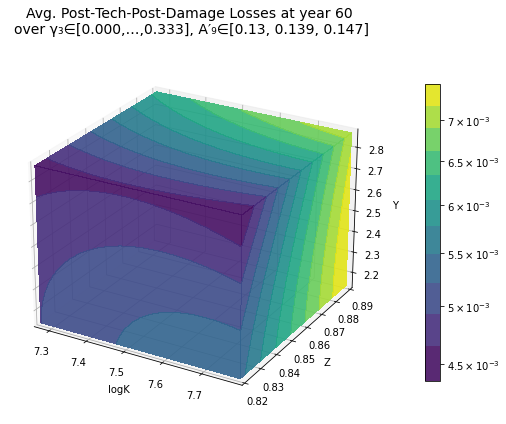

In [18]:
def sample_post_damage_post_tech(gamma_3=0.17,A_g_prime = 0.139 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_Y      = 20

    logK_vals  = np.linspace(7.27,7.79,   N_logK)
    R_vals     = np.linspace(0.82, 0.89, N_R)
    Y_vals = np.linspace(2.14, 2.87, N_Y)

    # Build a mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_gamma_3     = tf.ones((num_points, 1), dtype=tf.float32) * gamma_3       # gamma_3=0
    tf_A_g_prime   = tf.ones((num_points, 1), dtype=tf.float32) * A_g_prime      # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = post_tech_post_damage_model.params["batch_size"]
    post_tech_post_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = post_tech_post_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base, 
    training         = False
    )

    # Restore original batch size
    post_tech_post_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_Y),LOGK , RRR,YYY
# 1) Build the two parameter lists from your model.params
gamma_3_list   = np.linspace(
    post_tech_post_damage_model.params["gamma_3_min"],
    post_tech_post_damage_model.params["gamma_3_max"],
    post_tech_post_damage_model.params["gamma_3_length"]
)
A_g_prime_list = post_tech_post_damage_model.params["A_g_prime_list"]

# 2) Pre-allocate storage for all the loss grids
#    We’ll grab one sample to get N_logK, N_R, N_Y & the coordinate meshes
_example_res, LOGK, RRR, YYY = sample_post_damage_post_tech(
    gamma_3=gamma_3_list[0],
    A_g_prime=A_g_prime_list[0],
    log_xi=-1
)
N_logK, N_R, N_Y = _example_res.shape

all_res = np.zeros((len(gamma_3_list), len(A_g_prime_list),
                    N_logK, N_R, N_Y),
                   dtype=np.float32)

# 3) Loop and fill
for i, gamma_3 in enumerate(gamma_3_list):
    for j, A_g_prime in enumerate(A_g_prime_list):
        res_grid, _, _, _ = sample_post_damage_post_tech(
            gamma_3   = gamma_3,
            A_g_prime = A_g_prime,
            log_xi    = -1
        )
        all_res[i, j] = res_grid

# 4) Average over the first two axes (gamma_3 & A_g_prime)
mean_residual = all_res.mean(axis=(0,1))

print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 5) Plotting function for the averaged post‑post surface
def plot3D_post_damage_post_tech(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()
    
    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)
    
    fig = plt.figure(figsize=(8,6))
    ax  = fig.add_subplot(111, projection='3d')
    
    # face at Y = Y_max
    c1 = ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    c2 = ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")
    
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()    
    ax.set_title("Avg. Post‑Tech‑Post‑Damage Losses at year 60 \n" +
                 f"over γ₃∈[{gamma_3_list[0]:.3f},…,{gamma_3_list[-1]:.3f}], " +
                 f"A′₉∈{A_g_prime_list}",
                 fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 6) Finally call it:
plot3D_post_damage_post_tech(mean_residual, LOGK, RRR, YYY)

Average PDE residual: 6.54e-03


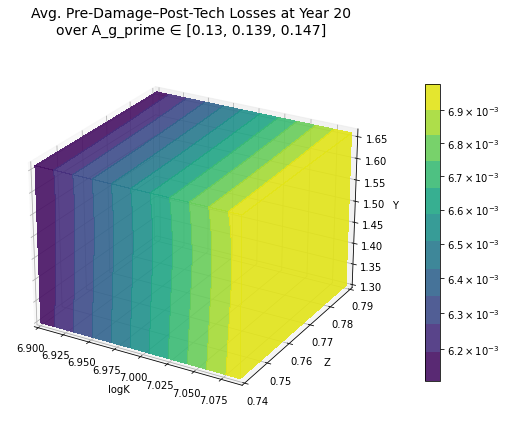

In [19]:
def sample_pre_damage_post_tech( A_g_prime = 0.139 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_Y      = 20

    logK_vals  = np.linspace(6.9, 7.09, N_logK)
    R_vals     = np.linspace(0.74, 0.79, N_R)
    Y_vals = np.linspace(1.30, 1.66, N_Y)

    # Build a mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_gamma_3     = tf.ones((num_points, 1), dtype=tf.float32) * 0      # gamma_3=0
    tf_A_g_prime   = tf.ones((num_points, 1), dtype=tf.float32) * A_g_prime      # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = post_tech_pre_damage_model.params["batch_size"]
    post_tech_pre_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = post_tech_pre_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base, 
    training         = False
    )

    # Restore original batch size
    post_tech_pre_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_Y),LOGK , RRR,YYY
 

# 1) pull your A_g_prime_list out of the model
A_g_prime_list = post_tech_pre_damage_model.params["A_g_prime_list"]

# 2) grab one sample to infer grid dims & meshes
_example_res, LOGK, RRR, YYY = sample_pre_damage_post_tech(
    A_g_prime = A_g_prime_list[0],
    log_xi    = -1
)
N_logK, N_R, N_Y = _example_res.shape

# 3) allocate array [nA, N_logK, N_R, N_Y]
all_res = np.zeros((len(A_g_prime_list), N_logK, N_R, N_Y), dtype=np.float32)

# 4) fill it
for i, A_g in enumerate(A_g_prime_list):
    res_grid, _, _, _ = sample_pre_damage_post_tech(
        A_g_prime = A_g,
        log_xi    = -1
    )
    all_res[i] = res_grid

# 5) average over A_g_prime
mean_residual = all_res.mean(axis=0)
print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 6) plotting helper
def plot3D_pre_damage_post_tech_avg(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max, **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min, **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max, **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    title = (
        "Avg. Pre‑Damage–Post‑Tech Losses at Year 20\n"
        f"over A_g_prime ∈ {A_g_prime_list}"
    )
    ax.set_title(title, fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 7) call it
plot3D_pre_damage_post_tech_avg(mean_residual, LOGK, RRR, YYY)


Average PDE residual: 8.40e-03


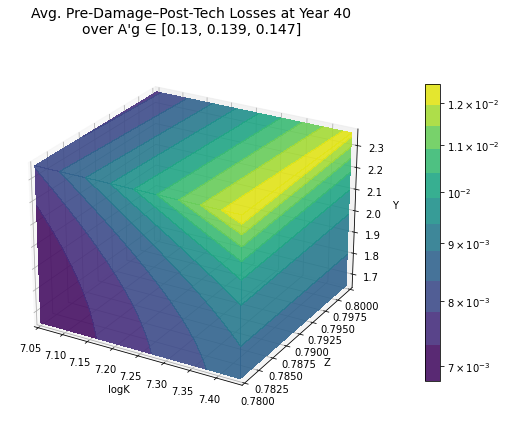

In [20]:
def sample_pre_damage_post_tech( A_g_prime = 0.139 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_Y      = 20


    logK_vals  = np.linspace(7.05, 7.44, N_logK)
    R_vals     = np.linspace(0.78, 0.8, N_R)
    Y_vals = np.linspace(1.65, 2.36, N_Y)

    # Build a mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_gamma_3     = tf.ones((num_points, 1), dtype=tf.float32) * 0      # gamma_3=0
    tf_A_g_prime   = tf.ones((num_points, 1), dtype=tf.float32) * A_g_prime      # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = post_tech_pre_damage_model.params["batch_size"]
    post_tech_pre_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = post_tech_pre_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base, 
    training         = False
    )

    # Restore original batch size
    post_tech_pre_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_Y),LOGK , RRR,YYY
 

# 1) pull your A_g_prime_list out of the model
A_g_prime_list = post_tech_pre_damage_model.params["A_g_prime_list"]

# 2) grab one sample to infer grid dims & meshes
_example_res, LOGK, RRR, YYY = sample_pre_damage_post_tech(
    A_g_prime = A_g_prime_list[0],
    log_xi    = -1
)
N_logK, N_R, N_Y = _example_res.shape

# 3) allocate array [nA, N_logK, N_R, N_Y]
all_res = np.zeros((len(A_g_prime_list), N_logK, N_R, N_Y), dtype=np.float32)

# 4) fill it
for i, A_g in enumerate(A_g_prime_list):
    res_grid, _, _, _ = sample_pre_damage_post_tech(
        A_g_prime = A_g,
        log_xi    = -1
    )
    all_res[i] = res_grid

# 5) average over A_g_prime
mean_residual = all_res.mean(axis=0)

print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 6) plotting helper
def plot3D_pre_damage_post_tech_avg(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max, **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min, **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max, **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    title = (
        "Avg. Pre‑Damage–Post‑Tech Losses at Year 40\n"
        f"over A'g ∈ {A_g_prime_list}"
    )
    ax.set_title(title, fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 7) call it
plot3D_pre_damage_post_tech_avg(mean_residual, LOGK, RRR, YYY)


Average PDE residual: 1.74e-02


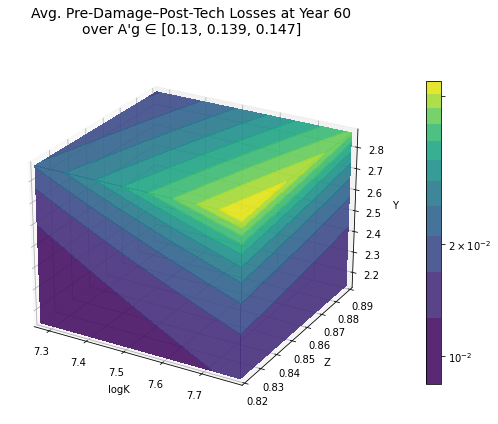

In [21]:
def sample_pre_damage_post_tech( A_g_prime = 0.139 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_Y      = 20

    logK_vals  = np.linspace(7.27,7.79,   N_logK)
    R_vals     = np.linspace(0.82, 0.89, N_R)
    Y_vals = np.linspace(2.14, 2.87, N_Y)
     

    # Build a mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_gamma_3     = tf.ones((num_points, 1), dtype=tf.float32) * 0      # gamma_3=0
    tf_A_g_prime   = tf.ones((num_points, 1), dtype=tf.float32) * A_g_prime      # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = post_tech_pre_damage_model.params["batch_size"]
    post_tech_pre_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = post_tech_pre_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base, 
    training         = False
    )

    # Restore original batch size
    post_tech_pre_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_Y),LOGK , RRR,YYY
 

# 1) pull your A_g_prime_list out of the model
A_g_prime_list = post_tech_pre_damage_model.params["A_g_prime_list"]

# 2) grab one sample to infer grid dims & meshes
_example_res, LOGK, RRR, YYY = sample_pre_damage_post_tech(
    A_g_prime = A_g_prime_list[0],
    log_xi    = -1
)
N_logK, N_R, N_Y = _example_res.shape

# 3) allocate array [nA, N_logK, N_R, N_Y]
all_res = np.zeros((len(A_g_prime_list), N_logK, N_R, N_Y), dtype=np.float32)

# 4) fill it
for i, A_g in enumerate(A_g_prime_list):
    res_grid, _, _, _ = sample_pre_damage_post_tech(
        A_g_prime = A_g,
        log_xi    = -1
    )
    all_res[i] = res_grid

# 5) average over A_g_prime
mean_residual = all_res.mean(axis=0)
print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 6) plotting helper
def plot3D_pre_damage_post_tech_avg(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max, **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min, **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max, **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    title = (
        "Avg. Pre‑Damage–Post‑Tech Losses at Year 60\n"
        f"over A'g ∈ {A_g_prime_list}"
    )
    ax.set_title(title, fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 7) call it
plot3D_pre_damage_post_tech_avg(mean_residual, LOGK, RRR, YYY)

Average PDE residual: 1.15e-03


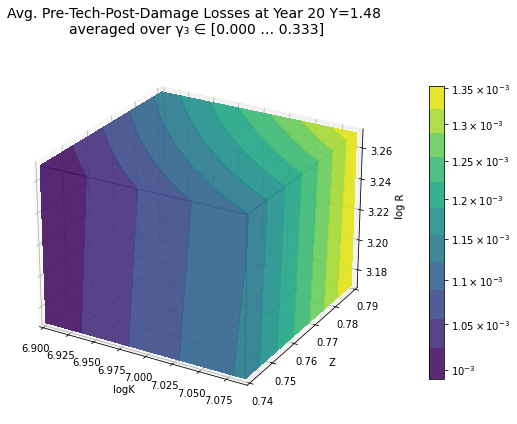

In [33]:
def sample_post_damage_pre_tech(gamma_3=0.16,Y=1.48 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_logIg  = 20

    logK_vals  = np.linspace(6.9, 7.09, N_logK)
    R_vals     = np.linspace(0.74, 0.79, N_R)
    logIg_vals = np.linspace(3.17, 3.27, N_logIg)

    # Build a mesh
    LOGK, RRR, LOGIG = np.meshgrid(logK_vals, R_vals, logIg_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), LOGIG.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_logIg = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1]
    tf_Y           = tf.ones((num_points, 1), dtype=tf.float32) * Y  # Y=1.5
    tf_gamma_3     = tf.ones((num_points, 1), dtype=tf.float32) *gamma_3       # gamma_3=0
    tf_A_g_prime   = tf.zeros((num_points, 1), dtype=tf.float32)       # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = pre_tech_post_damage_model.params["batch_size"]
    pre_tech_post_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = pre_tech_post_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base,
    log_I_g          = tf_logIg, 
    training         = False
    )

    # Restore original batch size
    pre_tech_post_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_logIg),LOGK , RRR,LOGIG

gamma_3_list = pre_tech_post_damage_model.params["gamma_3_list"]

# 2) do one sample to infer grid size & meshes
_res0, LOGK, RRR, LOGIG = sample_post_damage_pre_tech(
    gamma_3=gamma_3_list[0],
    Y=1.48,
    log_xi=-1
)
N_logK, N_R, N_logIg = _res0.shape

# 3) allocate array [n_gamma, N_logK, N_R, N_logIg]
all_res = np.zeros((len(gamma_3_list), N_logK, N_R, N_logIg), dtype=np.float32)

# 4) fill it
for i, γ3 in enumerate(gamma_3_list):
    res_grid, _, _, _ = sample_post_damage_pre_tech(
        gamma_3=γ3,
        Y=1.48,
        log_xi=-1
    )
    all_res[i] = res_grid

# 5) average over the gamma_3 axis
mean_residual = all_res.mean(axis=0)

print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

def plot3D_pre_tech_post_damage_avg(mean_res, LOGK, RRR, LOGIG, gamma_3_list):
    # compute axis limits once
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = LOGIG.min(), LOGIG.max()

    # contour levels
    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at log_I_g (Z) = z_max
    ax.contourf(
        LOGK[:, :, -1],
        RRR[:, :, -1],
        mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **contour_kw
    )

    # face at R = y_min
    ax.contourf(
        LOGK[:, 0, :],
        mean_res[:, 0, :],
        LOGIG[:, 0, :],
        zdir='y', offset=y_min,
        **contour_kw
    )

    # face at logK = x_max
    c3 = ax.contourf(
        mean_res[-1, :, :],
        RRR[-1, :, :],
        LOGIG[-1, :, :],
        zdir='x', offset=x_max,
        **contour_kw
    )

    # set limits and labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("log R")

    # colorbar and title
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    ax.set_title(
        "Avg. Pre‑Tech‑Post‑Damage Losses at Year 20 Y=1.48 \n"
        f"averaged over γ₃ ∈ [{gamma_3_list[0]:.3f} … {gamma_3_list[-1]:.3f}]",
        fontsize=14, pad=15
    )

    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()
    
plot3D_pre_tech_post_damage_avg(mean_residual, LOGK, RRR, LOGIG, gamma_3_list)

Average PDE residual (avg over γ₃ & Y): 1.15e-03


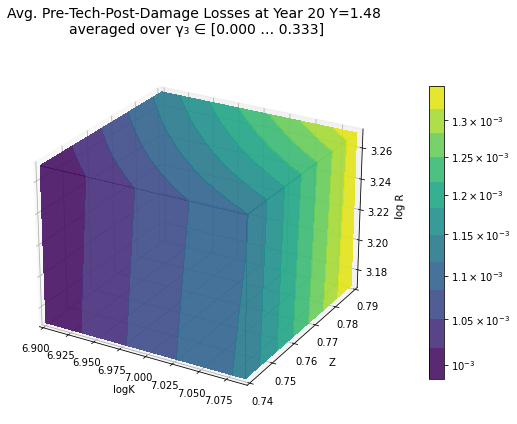

In [34]:
import numpy as np

# 1) set up your Y‐grid
N_Y   = 20
Y_vals = np.linspace(1.30, 1.66, N_Y)

# 2) pull your gamma_3 list
gamma_3_list = pre_tech_post_damage_model.params["gamma_3_list"]

# 3) sample once to infer dimensions & meshes
_res0, LOGK, RRR, LOGIG = sample_post_damage_pre_tech(
    gamma_3 = gamma_3_list[0],
    Y       = Y_vals[0],
    log_xi  = -1
)
N_logK, N_R, N_logIg = _res0.shape

# 4) allocate an array to hold [γ₃, Y, logK, R, logIg]
all_res = np.zeros((len(gamma_3_list), N_Y, N_logK, N_R, N_logIg), dtype=np.float32)

# 5) double loop over γ₃ and Y
for i, g3 in enumerate(gamma_3_list):
    for j, Y_val in enumerate(Y_vals):
        grid, _, _, _ = sample_post_damage_pre_tech(
            gamma_3 = g3,
            Y       = Y_val,
            log_xi  = -1
        )
        all_res[i, j] = grid

# 6) now average over both axes 0 and 1 (γ₃ and Y)
mean_residual = all_res.mean(axis=(0, 1))

# 7) inspect overall mean
print("Average PDE residual (avg over γ₃ & Y): {:.2e}".format(mean_residual.mean()))

# 8) plot using your existing 3D routine
plot3D_pre_tech_post_damage_avg(
    mean_res   = mean_residual,
    LOGK       = LOGK,
    RRR        = RRR,
    LOGIG      = LOGIG,
    gamma_3_list = gamma_3_list
)


Average PDE residual: 1.87e-03


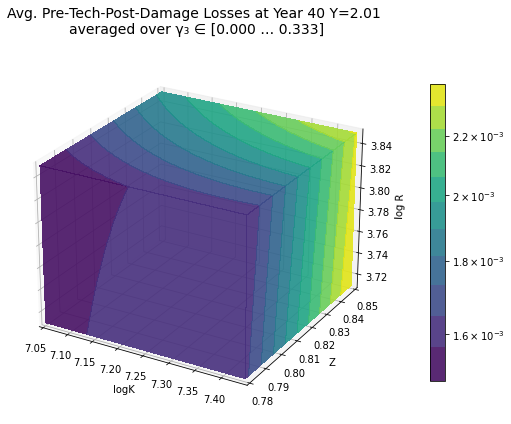

In [35]:
def sample_post_damage_pre_tech(gamma_3=0.16,Y=1.48 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_logIg  = 20

    logK_vals  = np.linspace(7.05, 7.44, N_logK)
    R_vals     = np.linspace(0.78, 0.85, N_R)
    logIg_vals = np.linspace(3.71, 3.85, N_logIg)

    # Build a mesh
    LOGK, RRR, LOGIG = np.meshgrid(logK_vals, R_vals, logIg_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), LOGIG.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_logIg = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1]
    tf_Y           = tf.ones((num_points, 1), dtype=tf.float32) * Y  # Y=1.5
    tf_gamma_3     = tf.ones((num_points, 1), dtype=tf.float32) *gamma_3       # gamma_3=0
    tf_A_g_prime   = tf.zeros((num_points, 1), dtype=tf.float32)       # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = pre_tech_post_damage_model.params["batch_size"]
    pre_tech_post_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = pre_tech_post_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base,
    log_I_g          = tf_logIg, 
    training         = False
    )

    # Restore original batch size
    pre_tech_post_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_logIg),LOGK , RRR,LOGIG

gamma_3_list = pre_tech_post_damage_model.params["gamma_3_list"]

# 2) do one sample to infer grid size & meshes
_res0, LOGK, RRR, LOGIG = sample_post_damage_pre_tech(
    gamma_3=gamma_3_list[0],
    Y=2.01,
    log_xi=-1
)
N_logK, N_R, N_logIg = _res0.shape

# 3) allocate array [n_gamma, N_logK, N_R, N_logIg]
all_res = np.zeros((len(gamma_3_list), N_logK, N_R, N_logIg), dtype=np.float32)

# 4) fill it
for i, γ3 in enumerate(gamma_3_list):
    res_grid, _, _, _ = sample_post_damage_pre_tech(
        gamma_3=γ3,
        Y=2.01,
        log_xi=-1
    )
    all_res[i] = res_grid

# 5) average over the gamma_3 axis
mean_residual = all_res.mean(axis=0)


print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

def plot3D_pre_tech_post_damage_avg(mean_res, LOGK, RRR, LOGIG, gamma_3_list):
    # compute axis limits once
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = LOGIG.min(), LOGIG.max()

    # contour levels
    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at log_I_g (Z) = z_max
    ax.contourf(
        LOGK[:, :, -1],
        RRR[:, :, -1],
        mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **contour_kw
    )

    # face at R = y_min
    ax.contourf(
        LOGK[:, 0, :],
        mean_res[:, 0, :],
        LOGIG[:, 0, :],
        zdir='y', offset=y_min,
        **contour_kw
    )

    # face at logK = x_max
    c3 = ax.contourf(
        mean_res[-1, :, :],
        RRR[-1, :, :],
        LOGIG[-1, :, :],
        zdir='x', offset=x_max,
        **contour_kw
    )

    # set limits and labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("log R")

    # colorbar and title
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1)
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    ax.set_title(
        "Avg. Pre‑Tech‑Post‑Damage Losses at Year 40 Y=2.01 \n"
        f"averaged over γ₃ ∈ [{gamma_3_list[0]:.3f} … {gamma_3_list[-1]:.3f}]",
        fontsize=14, pad=15
    )

    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()
    
plot3D_pre_tech_post_damage_avg(mean_residual, LOGK, RRR, LOGIG, gamma_3_list)

Average PDE residual (avg over γ₃ & Y): 1.83e-03


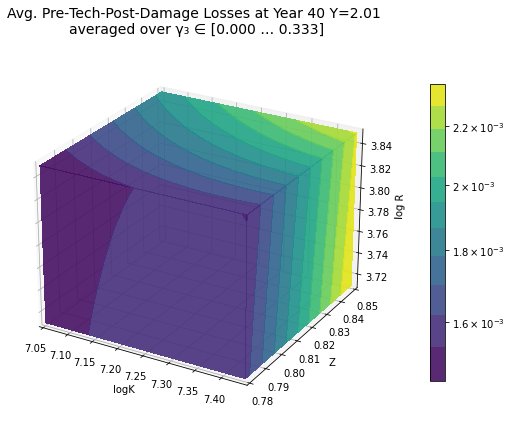

In [36]:
# 1) set up your Y‐grid
N_Y   = 20
Y_vals = np.linspace(1.65, 2.36, N_Y)

# 2) pull your gamma_3 list
gamma_3_list = pre_tech_post_damage_model.params["gamma_3_list"]

# 3) sample once to infer dimensions & meshes
_res0, LOGK, RRR, LOGIG = sample_post_damage_pre_tech(
    gamma_3 = gamma_3_list[0],
    Y       = Y_vals[0],
    log_xi  = -1
)
N_logK, N_R, N_logIg = _res0.shape

# 4) allocate an array to hold [γ₃, Y, logK, R, logIg]
all_res = np.zeros((len(gamma_3_list), N_Y, N_logK, N_R, N_logIg), dtype=np.float32)

# 5) double loop over γ₃ and Y
for i, g3 in enumerate(gamma_3_list):
    for j, Y_val in enumerate(Y_vals):
        grid, _, _, _ = sample_post_damage_pre_tech(
            gamma_3 = g3,
            Y       = Y_val,
            log_xi  = -1
        )
        all_res[i, j] = grid

# 6) now average over both axes 0 and 1 (γ₃ and Y)
mean_residual = all_res.mean(axis=(0, 1))

# 7) inspect overall mean
print("Average PDE residual (avg over γ₃ & Y): {:.2e}".format(mean_residual.mean()))

# 8) plot using your existing 3D routine
plot3D_pre_tech_post_damage_avg(
    mean_res   = mean_residual,
    LOGK       = LOGK,
    RRR        = RRR,
    LOGIG      = LOGIG,
    gamma_3_list = gamma_3_list
)

Average PDE residual: 2.16e-03


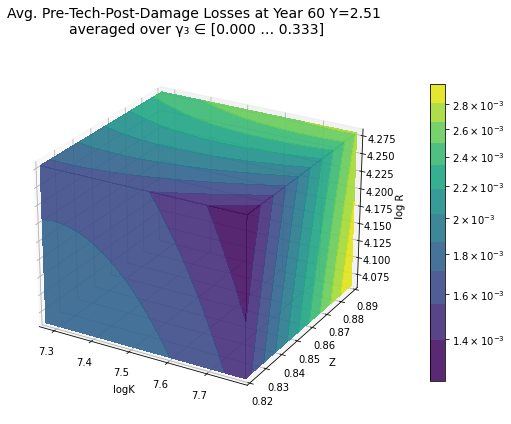

In [37]:
def sample_post_damage_pre_tech(gamma_3=0.16,Y=1.48 , log_xi=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_R      = 20
    N_logIg  = 20
 
    logK_vals  = np.linspace(7.27, 7.79, N_logK)
    R_vals     = np.linspace(0.82, 0.89, N_R) 
     
    logIg_vals = np.linspace(4.06, 4.28, N_logIg)
    
    # Build a mesh
    LOGK, RRR, LOGIG = np.meshgrid(logK_vals, R_vals, logIg_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), RRR.ravel(), LOGIG.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_R     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_logIg = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1]
    tf_Y           = tf.ones((num_points, 1), dtype=tf.float32) * Y  # Y=1.5
    tf_gamma_3     = tf.ones((num_points, 1), dtype=tf.float32) *gamma_3       # gamma_3=0
    tf_A_g_prime   = tf.zeros((num_points, 1), dtype=tf.float32)       # A_g'=0
    tf_log_xi      = tf.ones((num_points, 1), dtype=tf.float32) * log_xi       # log_xi=0
    tf_log_xi_base = tf.zeros((num_points, 1), dtype=tf.float32)       # log_xi_baseline=0

    # 2) Temporarily override the batch_size in self.params
    old_batch_size = pre_tech_post_damage_model.params["batch_size"]
    pre_tech_post_damage_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = pre_tech_post_damage_model.pde_rhs(
    logK             = tf_logK,
    R                = tf_R,
    Y                = tf_Y,
    gamma_3          = tf_gamma_3,
    A_g_prime        = tf_A_g_prime,
    log_xi           = tf_log_xi,
    log_xi_baseline  = tf_log_xi_base,
    log_I_g          = tf_logIg, 
    training         = False
    )

    # Restore original batch size
    pre_tech_post_damage_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_R, N_logIg),LOGK , RRR,LOGIG

gamma_3_list = pre_tech_post_damage_model.params["gamma_3_list"]

# 2) do one sample to infer grid size & meshes
_res0, LOGK, RRR, LOGIG = sample_post_damage_pre_tech(
    gamma_3=gamma_3_list[0],
    Y=2.51,
    log_xi=-1
)
N_logK, N_R, N_logIg = _res0.shape

# 3) allocate array [n_gamma, N_logK, N_R, N_logIg]
all_res = np.zeros((len(gamma_3_list), N_logK, N_R, N_logIg), dtype=np.float32)

# 4) fill it
for i, γ3 in enumerate(gamma_3_list):
    res_grid, _, _, _ = sample_post_damage_pre_tech(
        gamma_3=γ3,
        Y=2.51,
        log_xi=-1
    )
    all_res[i] = res_grid

# 5) average over the gamma_3 axis
mean_residual = all_res.mean(axis=0)



print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))



def plot3D_pre_tech_post_damage_avg(mean_res, LOGK, RRR, LOGIG, gamma_3_list):
    # compute axis limits once
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = LOGIG.min(), LOGIG.max()

    # contour levels
    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at log_I_g (Z) = z_max
    ax.contourf(
        LOGK[:, :, -1],
        RRR[:, :, -1],
        mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **contour_kw
    )

    # face at R = y_min
    ax.contourf(
        LOGK[:, 0, :],
        mean_res[:, 0, :],
        LOGIG[:, 0, :],
        zdir='y', offset=y_min,
        **contour_kw
    )

    # face at logK = x_max
    c3 = ax.contourf(
        mean_res[-1, :, :],
        RRR[-1, :, :],
        LOGIG[-1, :, :],
        zdir='x', offset=x_max,
        **contour_kw
    )

    # set limits and labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("log R")

    # colorbar and title
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1)
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    ax.set_title(
        "Avg. Pre‑Tech‑Post‑Damage Losses at Year 60 Y=2.51 \n"
        f"averaged over γ₃ ∈ [{gamma_3_list[0]:.3f} … {gamma_3_list[-1]:.3f}]",
        fontsize=14, pad=15
    )

    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()
    
plot3D_pre_tech_post_damage_avg(mean_residual, LOGK, RRR, LOGIG, gamma_3_list)

Average PDE residual (avg over γ₃ & Y): 2.13e-03


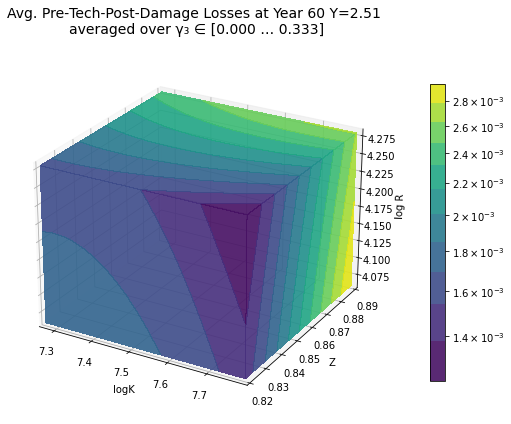

In [38]:
# 1) set up your Y‐grid
N_Y   = 20
Y_vals = np.linspace(2.14, 2.87, N_Y)

# 2) pull your gamma_3 list
gamma_3_list = pre_tech_post_damage_model.params["gamma_3_list"]

# 3) sample once to infer dimensions & meshes
_res0, LOGK, RRR, LOGIG = sample_post_damage_pre_tech(
    gamma_3 = gamma_3_list[0],
    Y       = Y_vals[0],
    log_xi  = -1
)
N_logK, N_R, N_logIg = _res0.shape

# 4) allocate an array to hold [γ₃, Y, logK, R, logIg]
all_res = np.zeros((len(gamma_3_list), N_Y, N_logK, N_R, N_logIg), dtype=np.float32)

# 5) double loop over γ₃ and Y
for i, g3 in enumerate(gamma_3_list):
    for j, Y_val in enumerate(Y_vals):
        grid, _, _, _ = sample_post_damage_pre_tech(
            gamma_3 = g3,
            Y       = Y_val,
            log_xi  = -1
        )
        all_res[i, j] = grid

# 6) now average over both axes 0 and 1 (γ₃ and Y)
mean_residual = all_res.mean(axis=(0, 1))

# 7) inspect overall mean
print("Average PDE residual (avg over γ₃ & Y): {:.2e}".format(mean_residual.mean()))

# 8) plot using your existing 3D routine
plot3D_pre_tech_post_damage_avg(
    mean_res   = mean_residual,
    LOGK       = LOGK,
    RRR        = RRR,
    LOGIG      = LOGIG,
    gamma_3_list = gamma_3_list
)

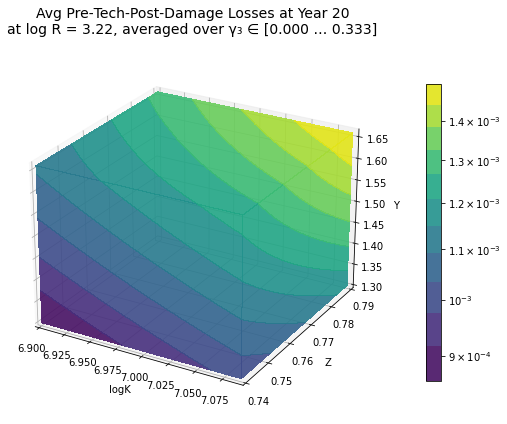

In [66]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def sample_pre_tech_post_damage_fixed_logIg(
    log_I_g=3.22,     # your fixed log_I_g
    gamma_3=0.16,     # one gamma_3 value
    Y=1.48,
    log_xi=-1.0
):
    # 1) grid sizes
    N_logK, N_R, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(6.90, 7.09, N_logK)
    R_vals     = np.linspace(0.74, 0.79, N_R)
    Y_vals     = np.linspace(1.30, 1.66, N_Y)

    # 3) mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # 4) flatten to batch
    pts     = np.stack([LOGK.ravel(), RRR.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    n_pts   = pts.shape[0]
    tf_logK = tf.reshape(tf.constant(pts[:, 0]), [n_pts, 1])
    tf_R    = tf.reshape(tf.constant(pts[:, 1]), [n_pts, 1])
    tf_Y    = tf.reshape(tf.constant(pts[:, 2]), [n_pts, 1])
    tf_logIg  = tf.ones((n_pts,1), dtype=tf.float32) * log_I_g

    # 5) other fixed tensors
    tf_gamma3      = tf.ones((n_pts,1), dtype=tf.float32) * gamma_3
    tf_Agprime     = tf.zeros((n_pts,1), dtype=tf.float32)
    tf_log_xi      = tf.ones((n_pts,1), dtype=tf.float32) * log_xi
    tf_log_xi_base = tf.zeros((n_pts,1), dtype=tf.float32)

    # 6) override batch size
    old_bs = pre_tech_post_damage_model.params["batch_size"]
    pre_tech_post_damage_model.params["batch_size"] = n_pts

    # 7) evaluate PDE rhs
    outputs = pre_tech_post_damage_model.pde_rhs(
        logK            = tf_logK,
        R               = tf_R,
        Y               = tf_Y,
        gamma_3         = tf_gamma3,
        A_g_prime       = tf_Agprime,
        log_xi          = tf_log_xi,
        log_xi_baseline = tf_log_xi_base,
        log_I_g         = tf_logIg,
        training        = False
    )

    # restore batch size
    pre_tech_post_damage_model.params["batch_size"] = old_bs

    # 8) compute residual from outputs[0] and outputs[1]
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    return resid.reshape(N_logK, N_R, N_Y), LOGK, RRR, YYY

# --- build and average over gamma_3 ---
gamma_3_list = pre_tech_post_damage_model.params["gamma_3_list"]
logIg_val    = 3.22   # choose your slice

# sample once for shapes
_sample, LOGK, RRR, YYY = sample_pre_tech_post_damage_fixed_logIg(
    log_I_g = logIg_val,
    gamma_3 = gamma_3_list[0],
    Y       = 1.48,
    log_xi  = -1
)
N_logK, N_R, N_Y = _sample.shape

# allocate storage
all_res = np.zeros((len(gamma_3_list), N_logK, N_R, N_Y), dtype=np.float32)

# loop
for i, g3 in enumerate(gamma_3_list):
    grid, _, _, _ = sample_pre_tech_post_damage_fixed_logIg(
        log_I_g = logIg_val,
        gamma_3 = g3,
        Y       = 1.48,
        log_xi  = -1
    )
    all_res[i] = grid

# mean across gamma_3
mean_residual = all_res.mean(axis=0)


# --- plotting function ---
def plot3D_fixed_logIg(mean_res, LOGK, RRR, YYY, logIg_val, gamma_3_list):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    ax.set_title(
        f"Avg Pre‑Tech‑Post‑Damage Losses at Year 20\n"
        f"at log R = {logIg_val:.2f}, averaged over γ₃ ∈ "
        f"[{gamma_3_list[0]:.3f} … {gamma_3_list[-1]:.3f}]",
        fontsize=14, pad=15
    )
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# --- call it ---
plot3D_fixed_logIg(
    mean_residual, LOGK, RRR, YYY,
    logIg_val=logIg_val,
    gamma_3_list=gamma_3_list
)


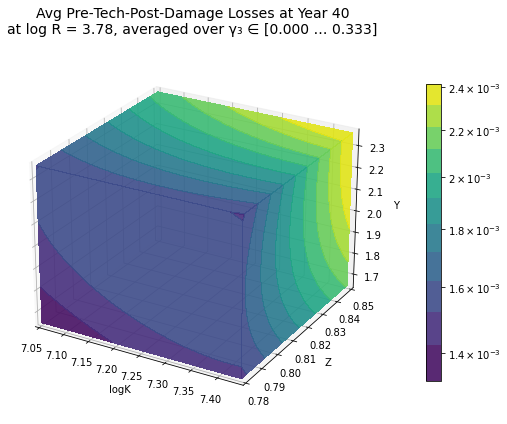

In [67]:
def sample_pre_tech_post_damage_fixed_logIg(
    log_I_g=3.22,     # your fixed log_I_g
    gamma_3=0.16,     # one gamma_3 value
    log_xi=-1.0
):
    # 1) grid sizes
    N_logK, N_R, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(7.05, 7.44, N_logK)
    R_vals     = np.linspace(0.78, 0.85, N_R)

    Y_vals     = np.linspace(1.65, 2.36, N_Y)

    # 3) mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # 4) flatten to batch
    pts     = np.stack([LOGK.ravel(), RRR.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    n_pts   = pts.shape[0]
    tf_logK = tf.reshape(tf.constant(pts[:, 0]), [n_pts, 1])
    tf_R    = tf.reshape(tf.constant(pts[:, 1]), [n_pts, 1])
    tf_Y    = tf.reshape(tf.constant(pts[:, 2]), [n_pts, 1])
    tf_logIg  = tf.ones((n_pts,1), dtype=tf.float32) * log_I_g

    # 5) other fixed tensors
    tf_gamma3      = tf.ones((n_pts,1), dtype=tf.float32) * gamma_3
    tf_Agprime     = tf.zeros((n_pts,1), dtype=tf.float32)
    tf_log_xi      = tf.ones((n_pts,1), dtype=tf.float32) * log_xi
    tf_log_xi_base = tf.zeros((n_pts,1), dtype=tf.float32)

    # 6) override batch size
    old_bs = pre_tech_post_damage_model.params["batch_size"]
    pre_tech_post_damage_model.params["batch_size"] = n_pts

    # 7) evaluate PDE rhs
    outputs = pre_tech_post_damage_model.pde_rhs(
        logK            = tf_logK,
        R               = tf_R,
        Y               = tf_Y,
        gamma_3         = tf_gamma3,
        A_g_prime       = tf_Agprime,
        log_xi          = tf_log_xi,
        log_xi_baseline = tf_log_xi_base,
        log_I_g         = tf_logIg,
        training        = False
    )

    # restore batch size
    pre_tech_post_damage_model.params["batch_size"] = old_bs

    # 8) compute residual from outputs[0] and outputs[1]
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    return resid.reshape(N_logK, N_R, N_Y), LOGK, RRR, YYY

# --- build and average over gamma_3 ---
gamma_3_list = pre_tech_post_damage_model.params["gamma_3_list"]
logIg_val    = 3.78   # choose your slice

# sample once for shapes
_sample, LOGK, RRR, YYY = sample_pre_tech_post_damage_fixed_logIg(
    log_I_g = logIg_val,
    gamma_3 = gamma_3_list[0],
    log_xi  = -1
)
N_logK, N_R, N_Y = _sample.shape

# allocate storage
all_res = np.zeros((len(gamma_3_list), N_logK, N_R, N_Y), dtype=np.float32)

# loop
for i, g3 in enumerate(gamma_3_list):
    grid, _, _, _ = sample_pre_tech_post_damage_fixed_logIg(
        log_I_g = logIg_val,
        gamma_3 = g3,
        log_xi  = -1
    )
    all_res[i] = grid

# mean across gamma_3
mean_residual = all_res.mean(axis=0)


# --- plotting function ---
def plot3D_fixed_logIg(mean_res, LOGK, RRR, YYY, logIg_val, gamma_3_list):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    ax.set_title(
        f"Avg Pre‑Tech‑Post‑Damage Losses at Year 40\n"
        f"at log R = {logIg_val:.2f}, averaged over γ₃ ∈ "
        f"[{gamma_3_list[0]:.3f} … {gamma_3_list[-1]:.3f}]",
        fontsize=14, pad=15
    )
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# --- call it ---
plot3D_fixed_logIg(
    mean_residual, LOGK, RRR, YYY,
    logIg_val=logIg_val,
    gamma_3_list=gamma_3_list
)


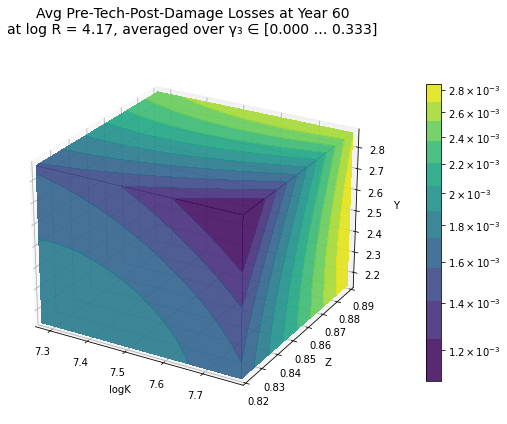

In [68]:
def sample_pre_tech_post_damage_fixed_logIg(
    log_I_g=3.22,     # your fixed log_I_g
    gamma_3=0.16,     # one gamma_3 value
    log_xi=-1.0
):
    # 1) grid sizes
    N_logK, N_R, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(7.27,7.79,   N_logK)
    R_vals     = np.linspace(0.82, 0.89, N_R)
    Y_vals     = np.linspace(2.14, 2.87, N_Y)

    # 3) mesh
    LOGK, RRR, YYY = np.meshgrid(logK_vals, R_vals, Y_vals, indexing="ij")

    # 4) flatten to batch
    pts     = np.stack([LOGK.ravel(), RRR.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    n_pts   = pts.shape[0]
    tf_logK = tf.reshape(tf.constant(pts[:, 0]), [n_pts, 1])
    tf_R    = tf.reshape(tf.constant(pts[:, 1]), [n_pts, 1])
    tf_Y    = tf.reshape(tf.constant(pts[:, 2]), [n_pts, 1])
    tf_logIg  = tf.ones((n_pts,1), dtype=tf.float32) * log_I_g

    # 5) other fixed tensors
    tf_gamma3      = tf.ones((n_pts,1), dtype=tf.float32) * gamma_3
    tf_Agprime     = tf.zeros((n_pts,1), dtype=tf.float32)
    tf_log_xi      = tf.ones((n_pts,1), dtype=tf.float32) * log_xi
    tf_log_xi_base = tf.zeros((n_pts,1), dtype=tf.float32)

    # 6) override batch size
    old_bs = pre_tech_post_damage_model.params["batch_size"]
    pre_tech_post_damage_model.params["batch_size"] = n_pts

    # 7) evaluate PDE rhs
    outputs = pre_tech_post_damage_model.pde_rhs(
        logK            = tf_logK,
        R               = tf_R,
        Y               = tf_Y,
        gamma_3         = tf_gamma3,
        A_g_prime       = tf_Agprime,
        log_xi          = tf_log_xi,
        log_xi_baseline = tf_log_xi_base,
        log_I_g         = tf_logIg,
        training        = False
    )

    # restore batch size
    pre_tech_post_damage_model.params["batch_size"] = old_bs

    # 8) compute residual from outputs[0] and outputs[1]
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    return resid.reshape(N_logK, N_R, N_Y), LOGK, RRR, YYY

# --- build and average over gamma_3 ---
gamma_3_list = pre_tech_post_damage_model.params["gamma_3_list"]
logIg_val    = 4.17   # choose your slice

# sample once for shapes
_sample, LOGK, RRR, YYY = sample_pre_tech_post_damage_fixed_logIg(
    log_I_g = logIg_val,
    gamma_3 = gamma_3_list[0],
    log_xi  = -1
)
N_logK, N_R, N_Y = _sample.shape

# allocate storage
all_res = np.zeros((len(gamma_3_list), N_logK, N_R, N_Y), dtype=np.float32)

# loop
for i, g3 in enumerate(gamma_3_list):
    grid, _, _, _ = sample_pre_tech_post_damage_fixed_logIg(
        log_I_g = logIg_val,
        gamma_3 = g3,
        log_xi  = -1
    )
    all_res[i] = grid

# mean across gamma_3
mean_residual = all_res.mean(axis=0)


# --- plotting function ---
def plot3D_fixed_logIg(mean_res, LOGK, RRR, YYY, logIg_val, gamma_3_list):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    ax.set_title(
        f"Avg Pre‑Tech‑Post‑Damage Losses at Year 60\n"
        f"at log R = {logIg_val:.2f}, averaged over γ₃ ∈ "
        f"[{gamma_3_list[0]:.3f} … {gamma_3_list[-1]:.3f}]",
        fontsize=14, pad=15
    )
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# --- call it ---
plot3D_fixed_logIg(
    mean_residual, LOGK, RRR, YYY,
    logIg_val=logIg_val,
    gamma_3_list=gamma_3_list
)